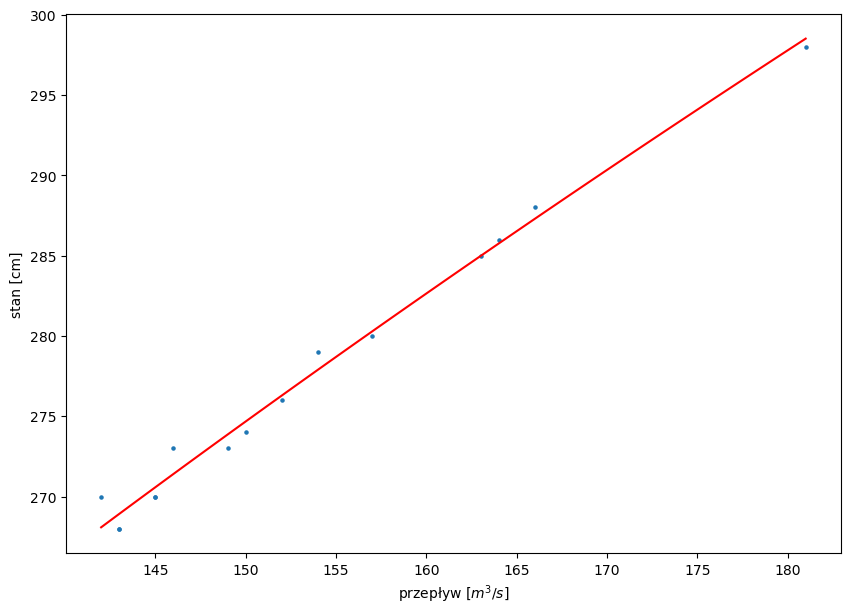

In [10]:
import numpy as np
import pandas as pd # biblioteka do manipulacji danymi
import os # biblioteka do obsługi systemu operacyjnego - tu do określenia ścieżki folderu roboczego
from tqdm import tqdm # biblioteka implementująca pasek postępu
import calendar
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# current_dir = os.getcwd()

df = pd.read_csv("merged_file.csv")
df = df.loc[(df['H [cm]']>265) & (df['H [cm]']<300),]
df = pd.DataFrame(df)
df = df.rename(columns={'Rok hydrologiczny':'Rh',
                        'Miesiac hydrologiczny':'Mh','Miesiac kalendarzowy':'Mk'}) #,'Miesiac kalendarzowy':'Mk'

df['H [cm]'] = df['H [cm]'].astype(float)
df['Q [m3/s]'] = df['Q [m3/s]'].astype(float)

y = df['H [cm]'].to_numpy()
x = df['Q [m3/s]'].to_numpy()

plt.figure(figsize=(10,7))
plt.scatter(x,y,s = 5)

coefficients = np.polyfit(np.log(x), np.log(y), 1)
m = coefficients[0]
b = np.exp(coefficients[1])
xx = np.linspace(x.min(),x.max(),100)

plt.plot(xx, b * np.power(xx, m), color='red')
plt.xlabel("przepływ [$m^3/s$]")
plt.ylabel('stan [cm]')
plt.show()

In [11]:
# b * np.power(, m)
m

0.4431061703364956

In [12]:
df = df.drop(['Kod stacji', 'Nazwa stacji', 'Nazwa rzeki/jeziora', 'Rh', 'Mh', 'Dzien', 'T [st. C]', 'Mk'], axis=1)
df = df.sort_values('H [cm]')
df = df.reset_index(drop=True)
df.index = df.index + 1
df.to_csv("tabela_wartości_H_Q.csv", sep=",", decimal=".", index = False, encoding = "utf-8")
df

,H [cm],Q [m3/s]
1,268.0,143.0
2,268.0,143.0
3,270.0,145.0
4,270.0,145.0
5,270.0,142.0
6,273.0,146.0
7,273.0,149.0
8,274.0,150.0
9,276.0,152.0
10,279.0,154.0


In [13]:
df['Y = ln Q'] = Y = np.log(df['Q [m3/s]'])
df['X = ln H'] = X = np.log(df['H [cm]']/100)
df['$X^2$'] = df['X = ln H']**2
df['XY'] = df['X = ln H'] * df['Y = ln Q']

w_1 = ( (X**2).sum() ) * ( Y.sum() ) - ( X.sum() ) * ( (X * Y).sum() )
w_2 = ( len(df) ) * ( (X * Y).sum() ) - ( X.sum() ) * ( Y.sum() )
w = ( len(df) ) * ( (X**2).sum() ) - ( X.sum() )**2
A_A = w_1 / w
B_B = w_2 / w
a_a = np.exp(A_A)
b_b = B_B
Q = a_a * 2.7**b_b
df

,H [cm],Q [m3/s],Y = ln Q,X = ln H,$X^2$,XY
1,268.0,143.0,4.962845,0.985817,0.971835,4.892456
2,268.0,143.0,4.962845,0.985817,0.971835,4.892456
3,270.0,145.0,4.976734,0.993252,0.986549,4.943150
4,270.0,145.0,4.976734,0.993252,0.986549,4.943150
5,270.0,142.0,4.955827,0.993252,0.986549,4.922384
6,273.0,146.0,4.983607,1.004302,1.008622,5.005044
7,273.0,149.0,5.003946,1.004302,1.008622,5.025471
8,274.0,150.0,5.010635,1.007958,1.015979,5.050510
9,276.0,152.0,5.023881,1.015231,1.030693,5.100398
10,279.0,154.0,5.036953,1.026042,1.052761,5.168123


In [14]:
df.to_csv("tabela_wartości_H_Q1.csv", sep=",", decimal=".", index = False, encoding = "utf-8")

In [15]:
Q = a_a * 1.9651**b_b
Q

71.10442571392363

In [17]:
a_a
b_b

2.229940732159004